# Self-Organizing Map (SOM) - PyTorch

Using device: cuda
Training SOM...
Epoch [10/100] completed
Epoch [20/100] completed
Epoch [30/100] completed
Epoch [40/100] completed
Epoch [50/100] completed
Epoch [60/100] completed
Epoch [70/100] completed
Epoch [80/100] completed
Epoch [90/100] completed
Epoch [100/100] completed
Training Finished!


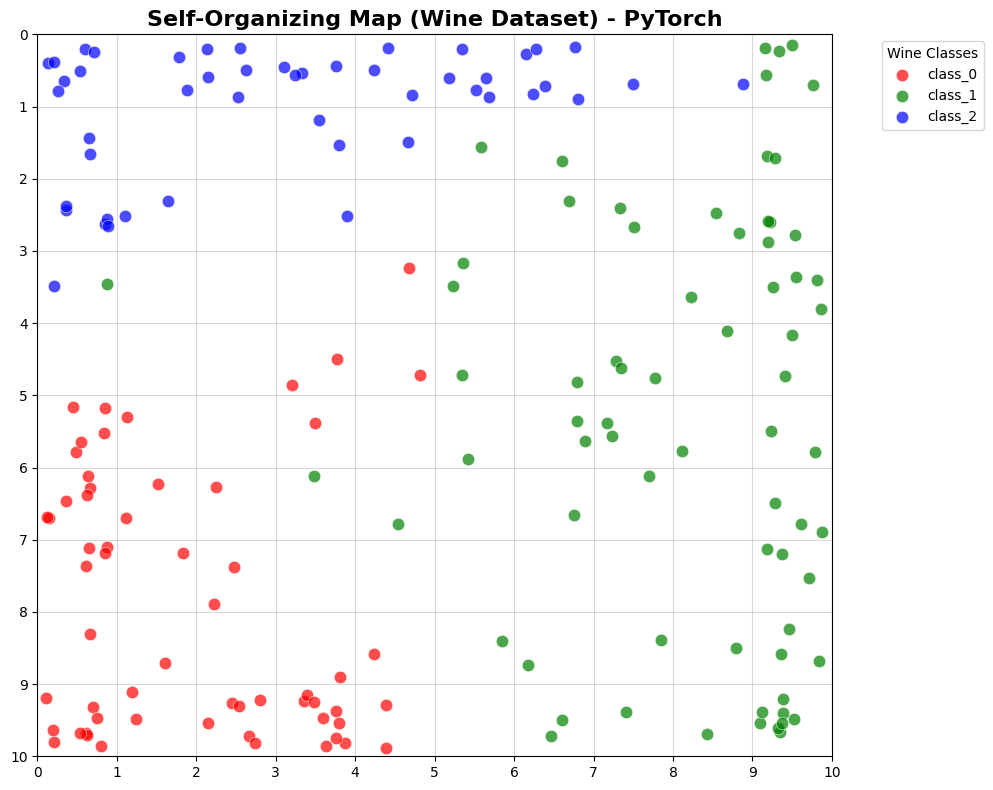

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# 1. Device Configuration
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# 2. Load and Normalize Dataset
# ============================================================
wine = load_wine()
X = wine.data
y = wine.target

# Normalize features to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert entire dataset to a PyTorch tensor
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

# ============================================================
# 3. SOM Parameters
# ============================================================
SOM_ROWS = 10
SOM_COLS = 10
INPUT_DIM = X.shape[1]

INITIAL_LEARNING_RATE = 0.5
INITIAL_SIGMA = max(SOM_ROWS, SOM_COLS) / 2.0
EPOCHS = 100

# ============================================================
# 4. Initialize Weights & Grid Coordinates
# ============================================================
# SOM weight matrix: Shape (10, 10, 13)
weights = torch.rand(SOM_ROWS, SOM_COLS, INPUT_DIM).to(device)

# Pre-compute a grid of coordinates for vectorized distance calculations
x_indices = torch.arange(SOM_COLS, dtype=torch.float32)
y_indices = torch.arange(SOM_ROWS, dtype=torch.float32)

# Create a 2D meshgrid (indexing='ij' ensures matrix-style y,x coordinates)
y_grid, x_grid = torch.meshgrid(y_indices, x_indices, indexing='ij')

# Shape: (10, 10, 2) where each element is [y, x]
grid_coords = torch.stack([y_grid, x_grid], dim=-1).to(device)

# ============================================================
# 5. Helper Functions
# ============================================================
def find_bmu(sample):
    """Finds the Best Matching Unit (BMU) for a given sample."""
    # Expand sample to broadcast across the weight matrix
    sample_expanded = sample.view(1, 1, INPUT_DIM)

    # Calculate squared Euclidean distance between sample and all weights
    distances = torch.sum((weights - sample_expanded) ** 2, dim=2)

    # Get the flat index of the minimum distance
    bmu_1d_index = torch.argmin(distances.view(-1))

    # Convert flat index to 2D coordinates
    bmu_y = torch.div(bmu_1d_index, SOM_COLS, rounding_mode='floor')
    bmu_x = bmu_1d_index % SOM_COLS

    return torch.tensor([bmu_y, bmu_x], dtype=torch.float32).to(device)

def update_weights_vectorized(sample, bmu_loc, epoch):
    """Updates the entire SOM weight matrix simultaneously."""
    global weights

    # Calculate decaying learning rate and sigma
    decay_factor = np.exp(-epoch / EPOCHS)
    lr_decay = INITIAL_LEARNING_RATE * decay_factor
    sigma_decay = INITIAL_SIGMA * decay_factor

    # 1. Calculate squared distance of every neuron in the grid to the BMU
    dist_sq_to_bmu = torch.sum((grid_coords - bmu_loc) ** 2, dim=-1)

    # 2. Calculate the neighborhood influence for every neuron
    neighborhood = torch.exp(-dist_sq_to_bmu / (2 * sigma_decay ** 2))
    influence = neighborhood * lr_decay

    # 3. Expand influence shape to (10, 10, 1) to broadcast against weights
    influence = influence.unsqueeze(-1)

    # 4. Update all weights in one vectorized operation
    weights += influence * (sample - weights)

# ============================================================
# 6. Train SOM
# ============================================================
print("Training SOM...")

for epoch in range(EPOCHS):
    # Shuffle dataset each epoch for better generalization
    indices = torch.randperm(X_tensor.size(0))

    for idx in indices:
        sample_tensor = X_tensor[idx]
        bmu_loc = find_bmu(sample_tensor)
        update_weights_vectorized(sample_tensor, bmu_loc, epoch)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{EPOCHS}] completed")

print("Training Finished!")

# ============================================================
# 7. Map Data to SOM Grid
# ============================================================
mapped_locations = []

for sample in X_tensor:
    bmu = find_bmu(sample)
    mapped_locations.append(bmu.cpu().numpy())

mapped_locations = np.array(mapped_locations)

# ============================================================
# 8. Visualization
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Colors for the 3 wine classes
colors = ['red', 'green', 'blue'] # Red, Green, Blue
class_names = wine.target_names

# Scatter plot each point slightly jittered so overlapping points are visible
for class_idx in range(len(colors)):
    class_mask = (y == class_idx)
    points = mapped_locations[class_mask]

    # Add random jitter between 0.1 and 0.9 to spread them out within the grid cell
    jitter_y = np.random.rand(len(points)) * 0.8 + 0.1
    jitter_x = np.random.rand(len(points)) * 0.8 + 0.1

    ax.scatter(
        points[:, 1] + jitter_x, # X coordinate
        points[:, 0] + jitter_y, # Y coordinate
        color=colors[class_idx],
        label=class_names[class_idx],
        s=80,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5
    )

ax.set_title("Self-Organizing Map (Wine Dataset) - PyTorch", fontsize=16, fontweight='bold')
ax.set_xlim([0, SOM_COLS])
ax.set_ylim([0, SOM_ROWS])

# Draw grid lines to clearly show the boundaries of the neurons
ax.set_xticks(np.arange(SOM_COLS + 1))
ax.set_yticks(np.arange(SOM_ROWS + 1))
ax.grid(True, linestyle='-', alpha=0.3, color='gray')

# Invert Y axis so (0,0) is at the top-left (standard matrix representation)
ax.invert_yaxis()

ax.legend(title="Wine Classes", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()